In [1]:

import os
import sys
import argparse
import datetime
import numpy as np
import time
import torch
import torch.backends.cudnn as cudnn
import json
from pathlib import Path
from collections import OrderedDict
from functools import partial

# Add project root to path
# sys.path.insert(0, str(Path(__file__).parent))

from timm.models import create_model
from timm.loss import LabelSmoothingCrossEntropy, SoftTargetCrossEntropy
from timm.scheduler import create_scheduler
from src.optim.optim_factory import create_optimizer, get_parameter_groups, LayerDecayValueAssigner

from timm.utils import ModelEma

from src.utils.config import get_cfg, merge_config_file, freeze_cfg, load_and_freeze_config
from src.engine.train_engine import TrainingEngine
from src.engine.val_engine import ValidationEngine
from src.utils.evaluation import merge_distributed_results
from src.optim.mixup import Mixup
# from src.optim.optim_factory import LayerDecayValueAssigner
from src.dataset.datasets import build_dataset
from src.utils.utils import NativeScalerWithGradNormCount as NativeScaler
from src.utils.utils import multiple_samples_collate
from src.utils.logger import TensorboardLogger
from src.utils import utils

from src.models import ViT, ViT_pretrain, layers

from run_finetuning_with_yacs import create_data_loaders, create_model_from_config

/root/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
config_path = 'configs/eve_finetune.yaml'
cfg = get_cfg()
merge_config_file(cfg, config_path)
cfg.SYSTEM.DISTRIBUTED = False  # Disable distributed training
cfg.batch_size = 2  # Set batch size to 2

In [3]:
data_loader_train, data_loader_val = create_data_loaders()
model = create_model_from_config()

Parsed 79713 video-frame pairs
First few pairs: [('/home/qzk/EVE/eve_dataset/train13/step027_image_MIT-i2130236527/basler_face.mp4', 90), ('/home/qzk/EVE/eve_dataset/train13/step027_image_MIT-i2130236527/basler_face.mp4', 120), ('/home/qzk/EVE/eve_dataset/train13/step027_image_MIT-i2130236527/basler_face.mp4', 150)]
Number of the class = 2
Parsed 9751 video-frame pairs
First few pairs: [('/home/qzk/EVE/eve_dataset/val04/step097_image_MIT-i1158903665/basler_face.mp4', 90), ('/home/qzk/EVE/eve_dataset/val04/step097_image_MIT-i1158903665/basler_face.mp4', 120), ('/home/qzk/EVE/eve_dataset/val04/step097_image_MIT-i1158903665/basler_face.mp4', 150)]
Number of the class = 2
[IN TIMM!] Creating model vit_base_dim512_no_depth_patch16_160 with source  and kwargs: {'num_classes': 2, 'all_frames': 16, 'tubelet_size': 2, 'drop_rate': 0.0, 'drop_path_rate': 0.1, 'attn_drop_rate': 0.0, 'use_mean_pooling': True, 'init_scale': 0.001, 'attn_type': 'local_global', 'lg_region_size': [2, 2, 10], 'lg_first

In [4]:
model_path = "/home/qzk/Facial-Foundation-Model/output/eve_debug/checkpoint-8.pth"
state_dict = torch.load(model_path, map_location='cpu', weights_only=False)
state_dict = state_dict["model"]
state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
model.load_state_dict(state_dict)

<All keys matched successfully>

In [5]:
# pick a sample from the training set
samples, targets, _, _ = next(iter(data_loader_train))
# samples, targets, _ = next(iter(data_loader_val))
# print("sample likely contains:", sample.keys())
# visualize the model output for the sample
with torch.no_grad():
    model.eval()
    print("shape of sample:", samples.shape)
    output = model(samples)
    print("output ", output)
    print("target", targets)



shape of sample: torch.Size([32, 3, 16, 160, 160])
output  tensor([[ 0.4858,  0.0814],
        [ 0.3268, -0.0259],
        [ 0.4567, -0.2867],
        [ 0.4611, -0.0275],
        [ 0.4630,  0.0656],
        [ 0.4270,  0.0048],
        [ 0.4250,  0.0224],
        [ 0.4328, -0.1900],
        [ 0.3912, -0.1844],
        [ 0.3474,  0.1783],
        [ 0.4522, -0.2613],
        [ 0.3491, -0.0530],
        [ 0.4090, -0.3060],
        [ 0.3146,  0.0522],
        [ 0.3855, -0.2625],
        [ 0.4583, -0.0331],
        [ 0.4834, -0.0608],
        [ 0.3700, -0.3148],
        [ 0.4363, -0.0520],
        [ 0.4785, -0.0433],
        [ 0.4408, -0.0217],
        [ 0.3781, -0.0219],
        [ 0.4290,  0.1615],
        [ 0.4304,  0.0569],
        [ 0.4155,  0.2799],
        [ 0.3920,  0.0007],
        [ 0.4677,  0.0950],
        [ 0.4451, -0.2234],
        [ 0.4376,  0.0536],
        [ 0.4310,  0.0858],
        [ 0.3487, -0.2155],
        [ 0.4172, -0.0109]])
target tensor([[ 0.5062,  0.0076],
        [

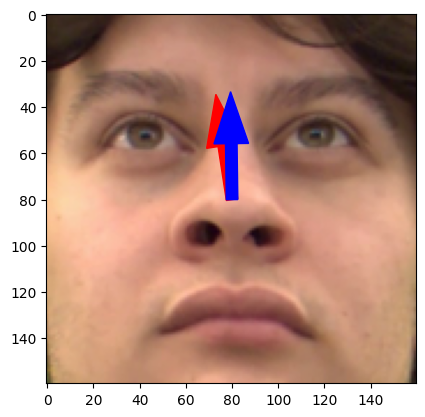

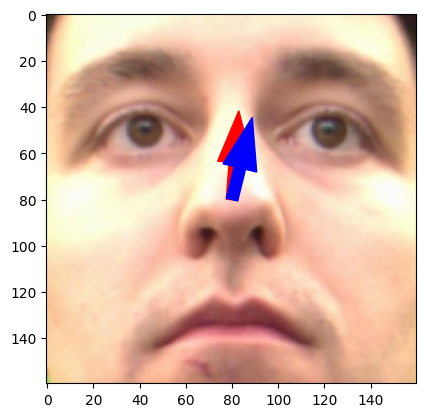

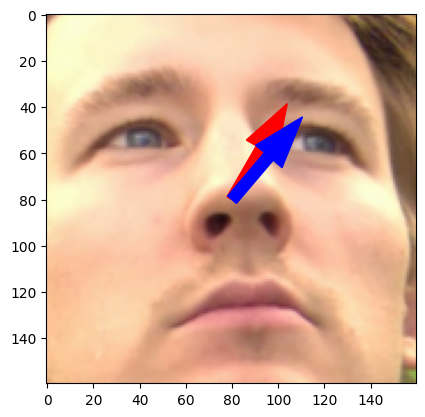

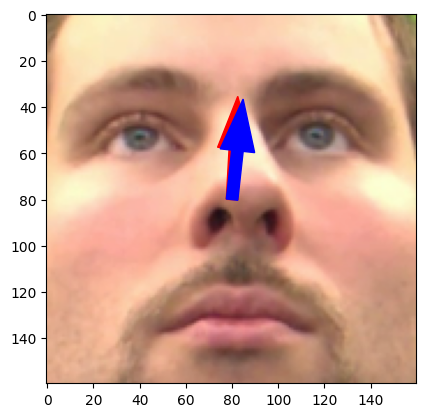

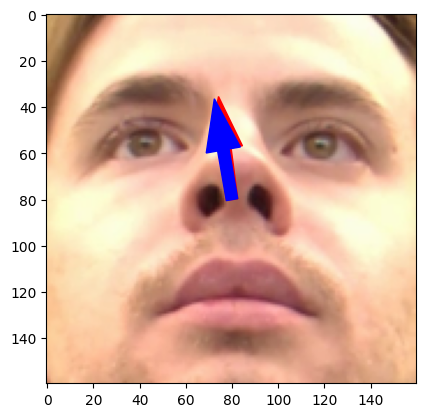

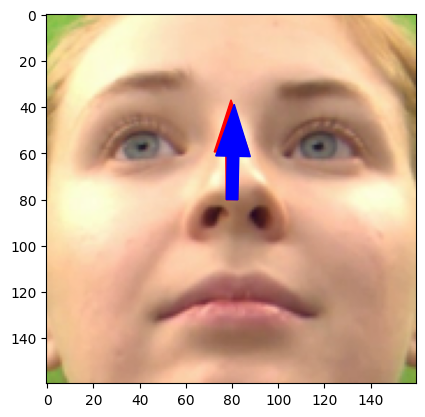

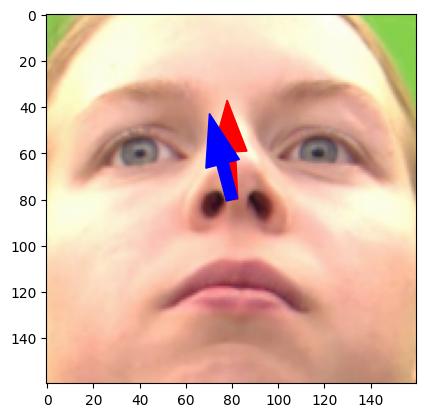

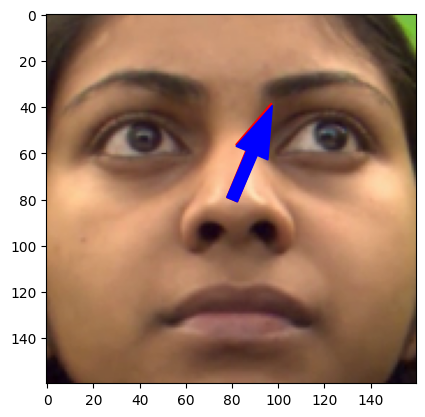

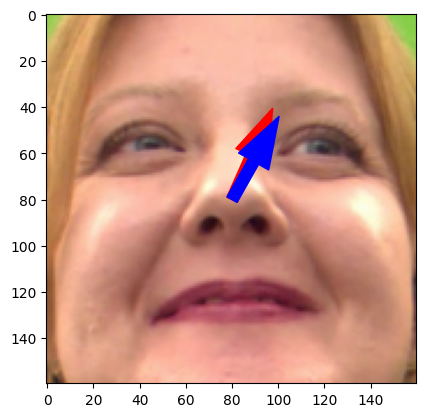

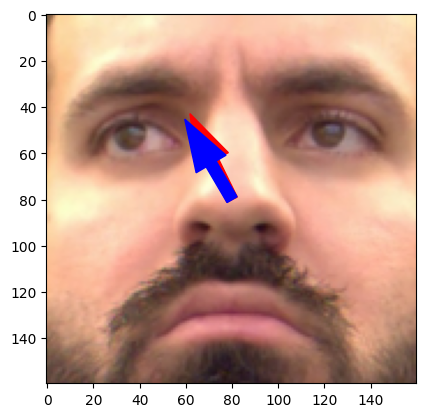

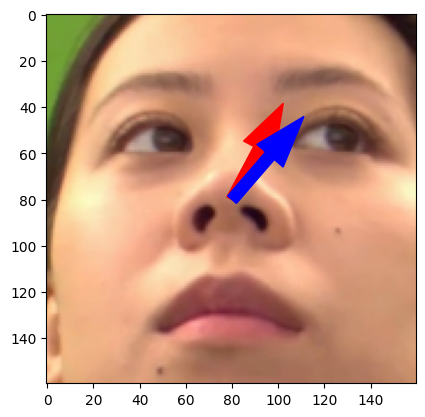

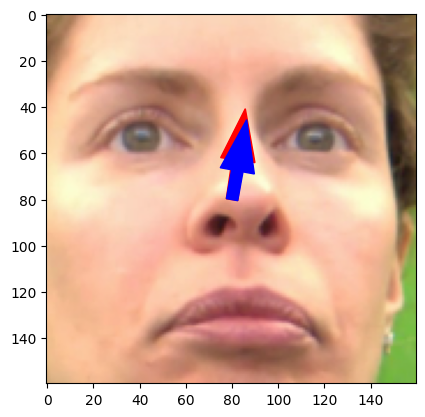

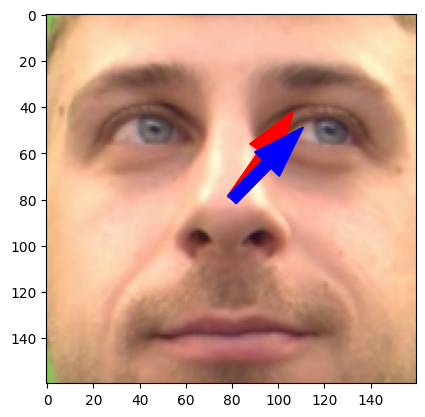

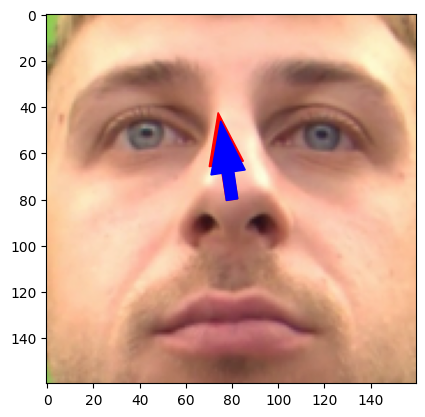

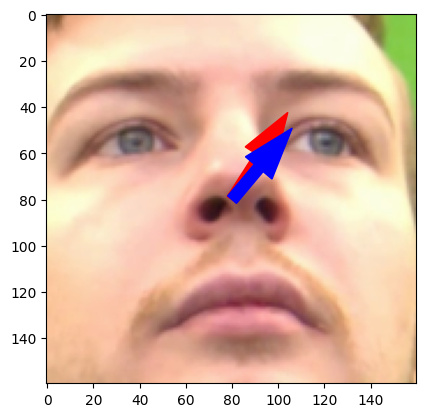

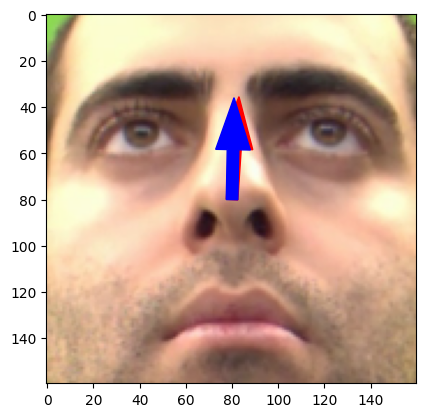

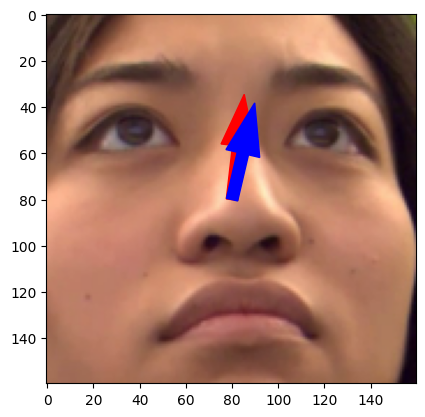

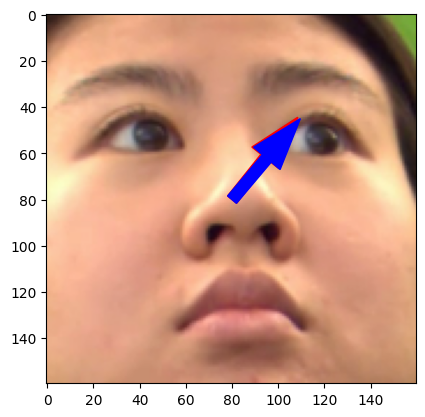

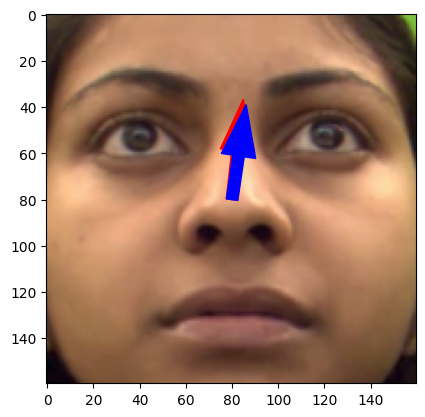

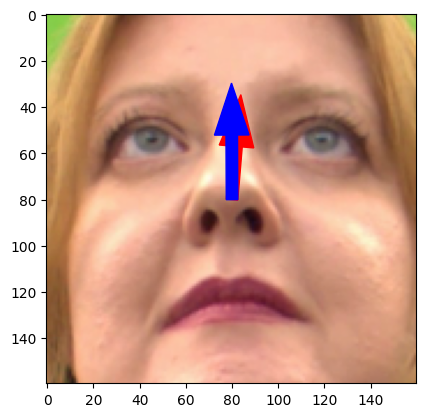

angular error:  3.861959218978882


In [9]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

def pitchyaw_to_vector(a):
    if a.shape[1] == 2:
        sin = torch.sin(a)
        cos = torch.cos(a)
        return torch.stack([cos[:, 0] * sin[:, 1], sin[:, 0], cos[:, 0] * cos[:, 1]], dim=1)
    elif a.shape[1] == 3:
        return F.normalize(a)
    else:
        raise ValueError('Do not know how to convert tensor of size %s' % a.shape)


for i, sample in enumerate(samples):
    if i >=20 :
        break
    img_to_show = sample[:,-1,...]
    img_to_show = img_to_show.permute(1, 2, 0).numpy()  # Convert to HWC format
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_to_show = img_to_show * std + mean  # Denormalize
    img_to_show = np.clip(img_to_show, 0, 1)  #
    img_to_show = (img_to_show * 255).astype(np.uint8)  # Convert to uint8 for display
    plt.imshow(img_to_show)
    # show the target and output angles
    target_angle = targets[i].numpy()
    output_angle = output[i].numpy()
    # plt.squiv
    pl0 = -np.cos(output_angle[0]) * np.sin(output_angle[1])
    pl1 = -np.sin(output_angle[0])
    
    
    # pl0 = output_angle[0]
    # pl1 = output_angle[1]
    # plt.Arrow(80, 80, pl0 * 500, pl1 * 500, width=50, color='red', label='Output Angle')
    plt.arrow(80, 80, pl0 * 50, pl1 * 50, width=5, color='red', label='Output Angle')
    ol0 = -np.cos(target_angle[0]) * np.sin(target_angle[1])
    ol1 = -np.sin(target_angle[0])
    # ol0 = target_angle[0]
    # ol1 = target_angle[1]
    plt.arrow(80, 80, ol0 * 50, ol1 * 50, width=5, color='blue', label='Target Angle')
    # plt.title(f'Sample {i} - Target Angle: {pl0} {pl1}, Output Angle: {ol0} {ol1}')
    plt.show()
    
pred_vecs = pitchyaw_to_vector(output)
target_vecs = pitchyaw_to_vector(targets)
sim = F.cosine_similarity(pred_vecs, target_vecs, dim=1, eps=1e-8)
sim = F.hardtanh_(sim, min_val=-1+1e-8, max_val=1-1e-8)
angular_err = torch.acos(sim) * 180. / np.pi
print("angular error: ", angular_err.mean().item())
    

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

for i, sample in enumerate(samples):
    print("sample shape:", sample.shape) # (3, 16, 160, 160)
    # record to a video file
    sample = sample.permute(1, 2, 3, 0)  # Change to (time, height, width, channels)
    sample = sample.detach().cpu().numpy()  # Convert to numpy array
    # add mean and std normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    sample = (sample * std + mean)  # Denormalize
    sample = np.clip(sample, 0, 1)  # Clip values to [0, 1]
    sample = (sample * 255).astype(np.uint8)  # Convert to uint8
    # sample = cv2.cvtColor(sample, cv2.COLOR_RGB2BGR)
    # record a video file
    video_path = f"output/data_debug/sample_video_{i}.mp4"
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    height, width, _ = sample[0].shape
    out = cv2.VideoWriter(video_path, fourcc, 30.0, (width, height))
    for frame in sample:
        out.write(frame)
    out.release()

sample shape: torch.Size([3, 16, 160, 160])
sample shape: torch.Size([3, 16, 160, 160])
sample shape: torch.Size([3, 16, 160, 160])
sample shape: torch.Size([3, 16, 160, 160])
sample shape: torch.Size([3, 16, 160, 160])
sample shape: torch.Size([3, 16, 160, 160])
sample shape: torch.Size([3, 16, 160, 160])
sample shape: torch.Size([3, 16, 160, 160])
sample shape: torch.Size([3, 16, 160, 160])
sample shape: torch.Size([3, 16, 160, 160])
sample shape: torch.Size([3, 16, 160, 160])
sample shape: torch.Size([3, 16, 160, 160])
sample shape: torch.Size([3, 16, 160, 160])
sample shape: torch.Size([3, 16, 160, 160])
sample shape: torch.Size([3, 16, 160, 160])
sample shape: torch.Size([3, 16, 160, 160])
sample shape: torch.Size([3, 16, 160, 160])
sample shape: torch.Size([3, 16, 160, 160])
sample shape: torch.Size([3, 16, 160, 160])
sample shape: torch.Size([3, 16, 160, 160])
sample shape: torch.Size([3, 16, 160, 160])
sample shape: torch.Size([3, 16, 160, 160])
sample shape: torch.Size([3, 16,